## 0. import

In [ ]:
# pip install xgboost lightgbm

In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier, plot_importance
from lightgbm import LGBMClassifier

In [3]:
RANDOM_STATE = 203

## 1. 데이터 준비

In [36]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

def to_grade(q):
    if q <= 4:
        return 'low'
    elif q <= 6:
        return 'medium'
    else:
        return 'high'

df['grade'] = df['quality'].apply(to_grade)

X = df.drop(columns=['quality', 'grade'])
y_raw = df['grade']

# XGBoost/LightGBM은 문자열 레이블을 숫자로 인코딩해야 함
le = LabelEncoder()
y = le.fit_transform(y_raw)  # low=0, medium=1, high=2 (알파벳순)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=RANDOM_STATE, stratify=y_train
)


(1599, 13)


## 2. XGBoost 실습

In [17]:
gamma_list = [0, 0.5, 1, 5, 10]
xgb_accuracy_list = []
best_iteration_list = []

print("====== XGBoost ======")
for g in gamma_list:
  xgb_clf = XGBClassifier(
      n_estimators=400, learning_rate=0.05, max_depth=3,
      gamma = g,
      early_stopping_rounds=50,
      objective='multi:softmax', num_class=3,
      eval_metric='mlogloss', random_state=RANDOM_STATE
  )
  start_time = time.time()
  xgb_clf.fit(
      X_tr, y_tr,
      eval_set=[(X_tr, y_tr), (X_val, y_val)],
      verbose=False
  )
  xgb_pred = xgb_clf.predict(X_test)
  xgb_accuracy = accuracy_score(y_test, xgb_pred)
  xgb_accuracy_list.append(xgb_accuracy)
  best_iteration_list.append(xgb_clf.best_iteration)
  print(f'\ngamma {g} 정확도: {xgb_accuracy:.4f}')
  print(f'gamma {g} 수행 시간: {time.time() - start_time:.1f} 초')
  print('실제 사용된 트리 개수(조기 중단 반영):', xgb_clf.best_iteration + 1)


====== XGBoost ======

gamma 0 정확도: 0.8562
gamma 0 수행 시간: 1.3 초
실제 사용된 트리 개수(조기 중단 반영): 163

gamma 0.5 정확도: 0.8594
gamma 0.5 수행 시간: 1.5 초
실제 사용된 트리 개수(조기 중단 반영): 400

gamma 1 정확도: 0.8469
gamma 1 수행 시간: 0.2 초
실제 사용된 트리 개수(조기 중단 반영): 118

gamma 5 정확도: 0.8344
gamma 5 수행 시간: 0.2 초
실제 사용된 트리 개수(조기 중단 반영): 142

gamma 10 정확도: 0.8250
gamma 10 수행 시간: 0.2 초
실제 사용된 트리 개수(조기 중단 반영): 50


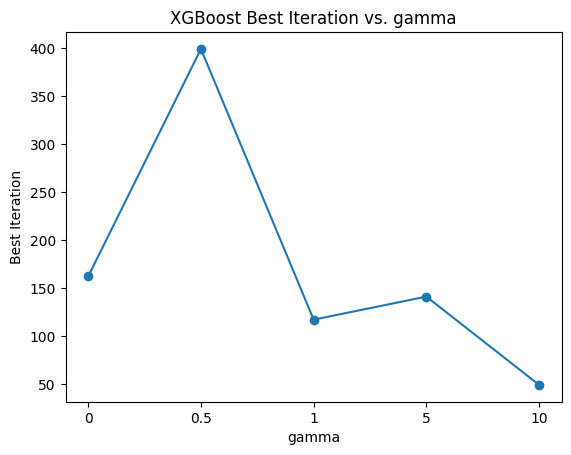

In [33]:
plt.plot(range(len(gamma_list)), best_iteration_list, marker='o')

plt.xlabel('gamma')
plt.ylabel('Best Iteration')
plt.title('XGBoost Best Iteration vs. gamma')

plt.xticks(range(len(gamma_list)), gamma_list)

plt.show()

## 3. LightGBM

In [39]:
lgbm_clf = LGBMClassifier(
    n_estimators=400, learning_rate=0.05, num_class=3,
    objective='multiclass', random_state=RANDOM_STATE,
    verbosity=-1
)

start_time = time.time()
lgbm_clf.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
)
lgbm_pred = lgbm_clf.predict(X_test)
lgbm_accuracy = accuracy_score(y_test, lgbm_pred)
print('LightGBM 정확도: {0:.4f}'.format(lgbm_accuracy))
print('LightGBM 수행 시간: {0:.1f} 초'.format(time.time() - start_time))

LightGBM 정확도: 0.8812
LightGBM 수행 시간: 1.2 초


## 4. XGBoost vs LightGBM 비교

In [22]:
start = time.time()
xgb_clf = XGBClassifier(
    n_estimators=400, learning_rate=0.05, max_depth=3,
    objective='multi:softmax', num_class=3,
    eval_metric='mlogloss', random_state=RANDOM_STATE
)
xgb_clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
xgb_time = time.time() - start
xgb_acc = xgb_clf.score(X_test, y_test)

start = time.time()
lgbm_clf = LGBMClassifier(
    n_estimators=400, learning_rate=0.05,
    objective='multiclass', num_class=3,
    random_state=RANDOM_STATE,
    verbosity=-1
)
lgbm_clf.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
lgbm_time = time.time() - start
lgbm_acc = lgbm_clf.score(X_test, y_test)

print(f'XGBoost 정확도: {xgb_acc:.4f}')
print(f'XGBoost 수행 시간: {xgb_time:.1f} 초')

print(f'LightGBM 정확도: {lgbm_acc:.4f}')
print(f'LightGBM 수행 시간: {lgbm_time:.1f} 초')


XGBoost 정확도: 0.8625
XGBoost 수행 시간: 1.0 초
LightGBM 정확도: 0.8812
LightGBM 수행 시간: 1.5 초


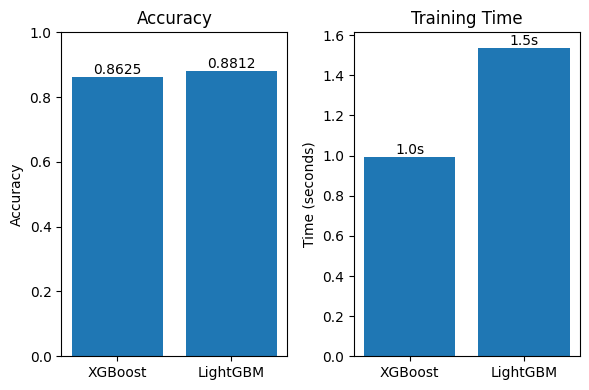

In [29]:
models = ['XGBoost', 'LightGBM']
accuracies = [xgb_acc, lgbm_acc]
times = [xgb_time, lgbm_time]

fig, axes = plt.subplots(1, 2, figsize=(6, 4))

# 정확도
bars1 = axes[0].bar(models, accuracies)

axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy')
axes[0].set_ylim(0, 1)

for bar, value in zip(bars1, accuracies):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:.4f}',
        ha='center',
        va='bottom'
    )


# 학습 시간
bars2 = axes[1].bar(models, times)

axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Training Time')

for bar, value in zip(bars2, times):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f'{value:.1f}s',
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

## 5. 2~5주차 전체 모델 비교

In [30]:
dt_clf = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
dt_clf.fit(X_train, y_train)

rf_clf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_train, y_train)

gb_clf = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_clf.fit(X_train, y_train)

summary = pd.DataFrame({
    'model': ['DecisionTree(2주차)', 'RandomForest(3주차)', 'GBM(4주차)', 'XGBoost(5주차)', 'LightGBM(5주차)'],
    'test_accuracy': [
        accuracy_score(y_test, dt_clf.predict(X_test)),
        accuracy_score(y_test, rf_clf.predict(X_test)),
        accuracy_score(y_test, gb_clf.predict(X_test)),
        xgb_accuracy,
        lgbm_accuracy,
    ]
})
print(summary)

               model  test_accuracy
0  DecisionTree(2주차)       0.818750
1  RandomForest(3주차)       0.853125
2           GBM(4주차)       0.834375
3       XGBoost(5주차)       0.825000
4      LightGBM(5주차)       0.881250


## 6. 특성 중요도 비교

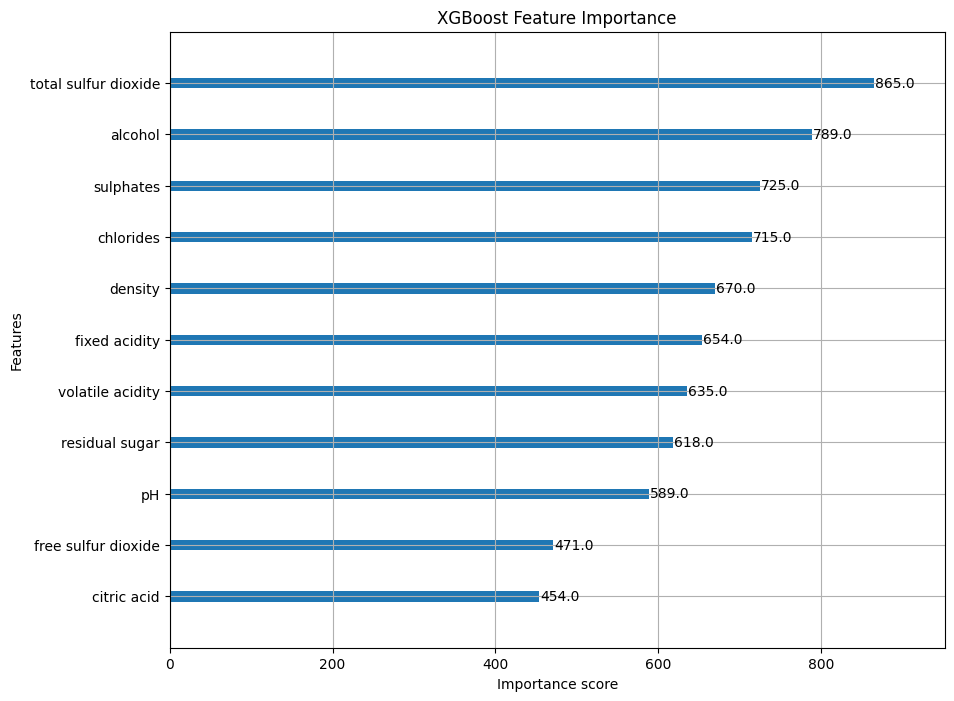

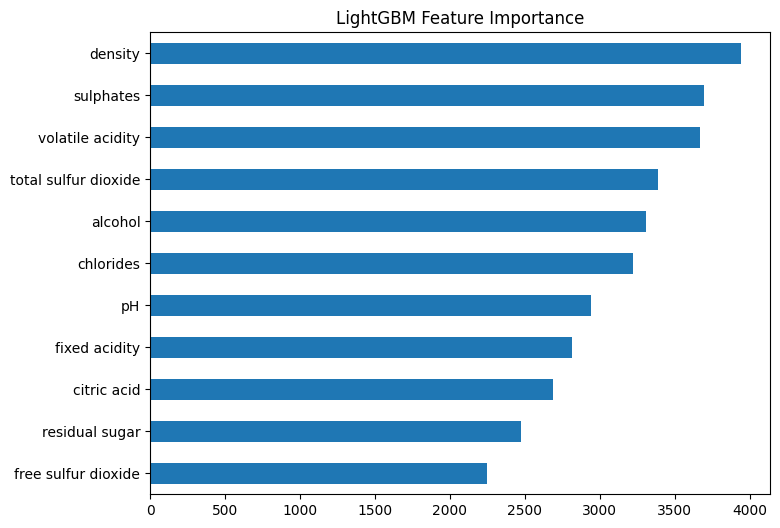

In [31]:
fig, ax = plt.subplots(figsize=(10, 8))
plot_importance(xgb_clf, ax=ax)
plt.title('XGBoost Feature Importance')
plt.show()

lgbm_importances = pd.Series(lgbm_clf.feature_importances_, index=X.columns)
lgbm_importances.sort_values(ascending=False).plot(kind='barh', figsize=(8, 6))
plt.title('LightGBM Feature Importance')
plt.gca().invert_yaxis()
plt.show()